<h1 style="color:red; text-align:center">
    Projet de machine learning :
    <br>
    -
    <br>
    Classification de la qualité du vin
</h1>

---
**INTRODUCTION**

Dans le cadre de ce projet, nous exploitons des données issues du dépôt **UC Irvine (UCI Machine Learning Repository)**. Deux jeux de données (red et white) y sont mis à disposition pour étudier la qualité du vin à partir de ses caractéristiques physico-chimiques, notamment ::

- **la teneur en acidité des vins**
- **la densité des vins**
- **le pH des vins**
- ...

L'objectif principal est de modéliser la variable cible `quality`, dont les scores s'étendent de 5 à 9. Pour maximiser la pertinence de nos modèles, nous formulons cet enjeu sous la forme d'un problème de **classification binaire** : un vin est considéré de "haute qualité" dès lors que sa note est **supérieure ou égale à 7**.

<u>Les différentes étapes de notre projet seront les suivantes :</u> 

1. **Consolidation du dateset**
2. **Analyse exploratoire des données (EDA)**
3. **Développement des modèles**
4. **Evaluation des modèles**
5. **Optimisation des hyperparamètres**

---

<h2 style="font-weight:bolder">I) Import des librairies</h2>

In [1]:
import os
import math
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

<h2 style="font-weight:bolder">II) Consolidation du dataset</h2>

Cette phase est très importante car c'est ce qui nous permettra de développer notre modèle après avoir réaliser une analyse exploratoire des données. Concrètement la consolidation du dataset revient à concatener les données du dataset `red` et `white`, car les variables sont les mêmes mais la couleur du vin change.

L'idée ici est donc pour chacun des datasets d'ajouter une colonne `color` puis de faire une concaténation des colonnes afin d'avoir notre dataset centralisée.

<h3 style="font-weight:bolder; color:blue">2.1) Liste des sources de données</h3>

In [2]:
os.listdir("./data")

['winequality-red.csv', 'winequality-white.csv', 'winequality.names']

<h3 style="font-weight:bolder; color:blue">2.2) Chargement du dataset <code>"df_red"</code></h3>

In [3]:
df_red = pd.read_csv("data/winequality-red.csv", sep=";")

<h4 style="color:green">2.2.1) Ajout de la colonne <code>"color"</code></h4>

In [4]:
df_red["color"] = "red"

In [5]:
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


<h3 style="font-weight:bolder; color:blue">2.3) Chargement du dataset <code>"df_white"</code></h3>

In [6]:
df_white = pd.read_csv("data/winequality-white.csv", sep=";")

<h4 style="color:green">2.3.1) Ajout de la colonne <code>"color"</code></h4>

In [7]:
df_white["color"] = "white"

In [8]:
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


<h3 style="font-weight:bolder; color:blue">2.4) Cohérence du nombre d'occurences</code></h3>

Ici nous calculons la somme du nombre d'occurence des datasets `red` et `white` avec la méthode `df.shape` avons concaténation afin de voir si cette somme sera la même après concaténation, c'est une étape de validation des données.

In [9]:
df_white.shape[0] + df_red.shape[0] # [0] pour récuperer le nombre de ligne

6497

<h3 style="font-weight:bolder; color:blue">2.5) Concaténation des datasets <code>"df_red"</code> X <code>"df_white"</code></h3>

Nous allons maintenant concatener nos datasets en un `dataframe` avec la méthode `pd.concat()` dans lequel toutes les prochaines étapes de transformations et de développement des modèles seront réalisés.

In [10]:
df = pd.concat([df_red, df_white], axis=0) # axis 0 pour concatener df_red "en dessous" de df_white

<h2 style="font-weight:bolder">III) Analyse Exploratoire des Données (EDA)</h2>

---
L'analyse exploratoire constitue une étape primordiale : elle permet d'appréhender la structure du jeu de données et d'orienter les choix de prétraitement requis pour optimiser la performance des modèles.

Toutes les variables fournies par la base **UC Irvine** étant de nature quantitative continue, l'enjeu principal réside dans l'étude fine de leurs distributions. Cette analyse vise notamment à :

- Identifier la forme des distributions
- Évaluer le besoin de transformations
- Analyser le déséquilibre de la variable cible
- Mesurer la corrélation entre les variables
---

À l'aide des méthodes `df.head()` et `df.tail()` nous allons afficher les 5 premières et dernières ligne de notre dataset afin de voir si la variable color a bien été concatener "en-dessous", avec les red au début de notre dataset et les white à la fin.

In [11]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [12]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
4897,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white


<h3 style="font-weight:bolder; color:blue">3.1) Dimensions du Dataset</h3>

Nous constatons ici les dimensions de notre dataset sont cohérentes avec le calcul effectué précédemment, nous avons bien $6497$ lignes après concaténation.

In [13]:
df.shape

(6497, 13)

<h3 style="font-weight:bolder; color:blue">3.2) Supression des doublons</h3>

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(5320, 13)

<h3 style="font-weight:bolder; color:blue">3.3) Informations du dataset</h3>

Afin d'avoir plus d'informations concernant notre dataset nous allons utiliser la méthode `df.info()` permettant de pouvoir visualiser :

1. **Index des colonnes**
2. **Noms des colonnes**
3. **Nombre de valeurs non nulles**
4. **Types de nos variables**

Après utilisation nous voyons que nous avons 13 variables et que 11 d'entre elles sont quantitatives et les variables $quality$ et $color$ sont qualitatives.

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 5320 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5320 non-null   float64
 1   volatile acidity      5320 non-null   float64
 2   citric acid           5320 non-null   float64
 3   residual sugar        5320 non-null   float64
 4   chlorides             5320 non-null   float64
 5   free sulfur dioxide   5320 non-null   float64
 6   total sulfur dioxide  5320 non-null   float64
 7   density               5320 non-null   float64
 8   pH                    5320 non-null   float64
 9   sulphates             5320 non-null   float64
 10  alcohol               5320 non-null   float64
 11  quality               5320 non-null   int64  
 12  color                 5320 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 605.8 KB


<h3 style="font-weight:bolder; color:blue">3.4) Description des données</h3>

La méthode `df.describe()` est particulièrement utile pour obtenir une vision synthétique des propriétés statistiques de chaque variable. Elle fournit un premier aperçu de :

- **la dispertion des données avec l'écart-type**
- **l'échelle des données avec le min et max**
- **l'existence d'outliers en observant l'écart en le 75% percentile et la valeur max**

In [17]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


<h3 style="font-weight:bolder; color:blue">3.5) Transformation du problème en classification binaire</h3>

Nous avons pour consigne de transformer ce problème de classification en un classification binaire, le `df.describe()` nous montre un **min à 3** et un **max à 9** pour la variable cible `quality`, pour nous assurer des différentes modalité nous allons afficher les modalités unique dans l'ordre croissant.

In [18]:
qualite_unique = df["quality"].unique()

print(np.sort(qualite_unique))

[3 4 5 6 7 8 9]


Nous constatons qu'il y'a des qualités de vins comprise entre $3$ et $9$, nous allons donc utiliser les méthodes `np.where()` et `df.between()` afin de toper toutes les **qualités comprise en 7 et 9** en $1$ représentant les bons vins et les autres à $0$.

In [19]:
df["quality"] = np.where(df["quality"].between(7, 9), "1", "0")

In [20]:
df["quality"].unique()

<ArrowStringArray>
['0', '1']
Length: 2, dtype: str

<h3 style="font-weight:bolder; color:blue">3.6) Analyse des variables qualitatives</h3>

Après avoir traité la variable cible nous pouvons à présent nous intéresser dans un premier temps aux répartitions des variables qualitatives :

- color : {red, white}
- quality : {0, 1}

Cette étape est importante ici afin de voir s'il existe un déséquilibre de classe pour la variable cible `quality`.

<h4 style="color:green">3.6.1) Analyse de la répartition de la couleur</h4>

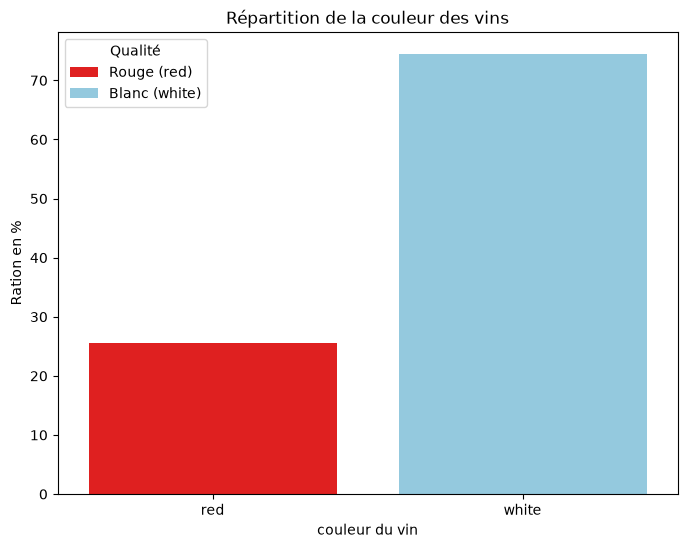

In [21]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="color",
    stat='percent',
    hue="color",
    palette={"white" : "skyblue", "red" : "red"}
)

plt.title("Répartition de la couleur des vins")
plt.ylabel("Ration en %")
plt.xlabel("couleur du vin")
plt.legend(title="Qualité", labels=["Rouge (red)", "Blanc (white)"])
plt.show()

In [22]:
df["color"].value_counts(normalize=True)

color
white    0.744549
red      0.255451
Name: proportion, dtype: float64

---
Ce `countplot` nous permet de constater qu'il y'a une majorité de vins blanc avec **75%** contre **25%** de vins rouge, ici nous ne pouvons pas encore tirer de réelle conclusion, mais il serait interéssant de voir si la couleur du vin influence sa qualité. 

---

<h4 style="color:green">3.6.2) Analyse de la répartition de la variable cible <code>quality</code></h4>

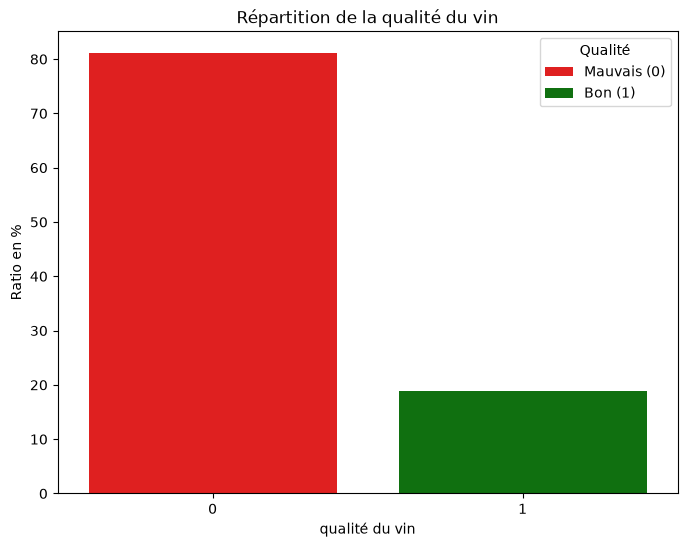

In [23]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="quality",
    stat="percent",
    hue="quality",
    palette={"0": "red", "1" : "green"}
)

plt.title("Répartition de la qualité du vin")
plt.ylabel("Ratio en %")
plt.xlabel("qualité du vin")
plt.legend(title="Qualité", labels=["Mauvais (0)", "Bon (1)"])
plt.show()

In [24]:
df["quality"].value_counts(normalize=True)

quality
0    0.810338
1    0.189662
Name: proportion, dtype: float64

---

Cette visualisation nous permet de constater un écart de la répartiton des classes $0$ et $1$ avec **80% de mauvais vins** contre **20% de bon**. C'est un paramètre très important qu'il faudra prendre en compte, car il faudra s'attendre à une sur-représentation de la classe $0$ lors des évaluations du modèle. Nous ne nous baserons pas sur l'exactitude globale, mais sur le $F1-Score$ et le $Recall$ de la classe $1$, tout en ajustant les poids des classes lors de l'entraînement.

---

<h4 style="color:green">3.6.3) Analyse de la répartition de la variable cible par couleur <code>quality</code></h4>

In [25]:
df.loc[df["quality"] == "0", "color"].value_counts(normalize=True)

color
white    0.727441
red      0.272559
Name: proportion, dtype: float64

In [26]:
df.loc[df["quality"] == '1', "color"].value_counts(normalize=True)

color
white    0.817641
red      0.182359
Name: proportion, dtype: float64

| Qualité (`quality`) | Vin blanc (`white`) | Vin rouge (`red`) | Total |
| :--- | :--- | :--- | :--- |
| **Classe 0** | 72.7% | 27.3% | 100% |
| **Classe 1** | 81.0% | 19.0% | 100% |

---

La proportion de vins blancs est plus élevée chez les bons vins avec $83$% contre $73.5$%, ce qui indique que la couleur apporte une légère information discriminante, mais pas suffisante à elle seule pour séparer nettement les classes. Nous allons maintenant nous interesser aux variables quantitatives afin d'essayer de trouver des discriminations possibles de la variable cible $quality$.

---

<h3 style="font-weight:bolder; color:blue">3.7) Analyse des variables quantitatives</h3>

<h4 style="color:green">3.7.1) Matrice de corrélation</h4>

L'analyse de la matrice de corrélation permet d'évaluer l'intensité des liaisons linéaires entre nos variables.

Dans notre jeu de données, la majorité des variables présentent de faibles corrélations croisées. Seuls deux couples dépassent le seuil de 0,70 :

- `total_sulfur_dioxyde X color`
- `total_sulfur_dioxyde X free_sulfur_dioxyde`

La redondance d'information globale étant faible, la création de variables synthétiques (ou une réduction de dimension systématique) risquerait d'entraîner une perte d'information inutile. Il est donc préférable de conserver l'ensemble des variables initiale.

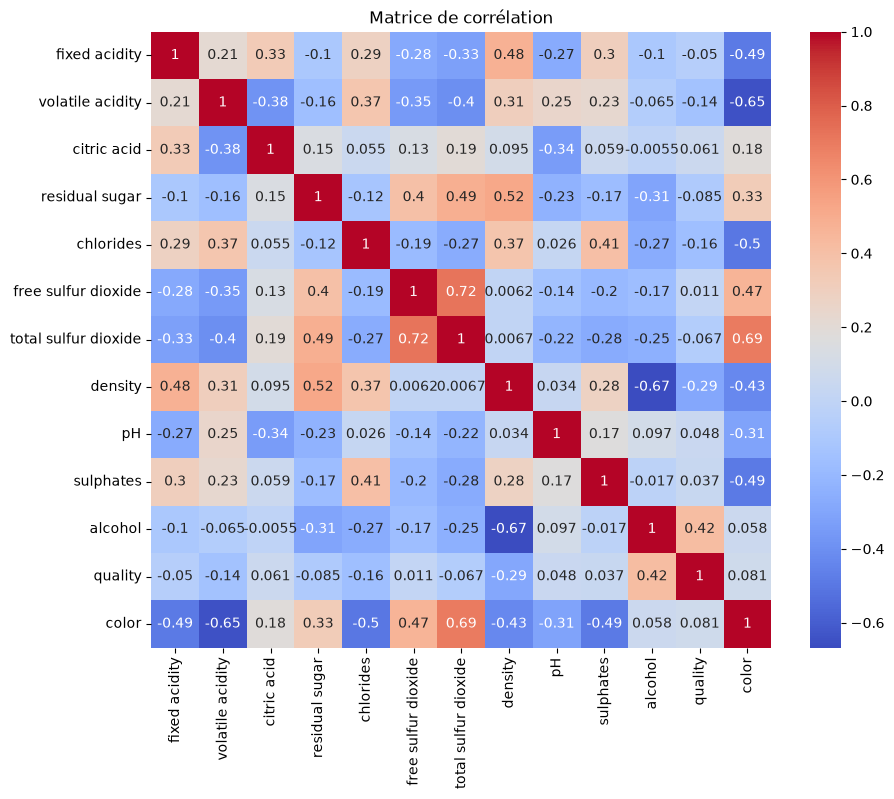

In [27]:
df_corr = df.copy()
df_corr["color"] = df_corr["color"].map({"red": 0, "white": 1})
df_corr["quality"] = df_corr["quality"].astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

<h4 style="color:green">3.7.2) Corrélation des variables avec `quality`</h4>

In [28]:
top_3 = {}

for col in df.columns:
    corr = df_corr[col].corr(df["quality"])
    if col != "quality":
        print(f"{col} X quality -> {corr}")
        top_3[col] = abs(corr)    

fixed acidity X quality -> -0.049840745699365405
volatile acidity X quality -> -0.1443614043727721
citric acid X quality -> 0.06067155060835996
residual sugar X quality -> -0.08486768169253765
chlorides X quality -> -0.16102727697120864
free sulfur dioxide X quality -> 0.01132519420701038
total sulfur dioxide X quality -> -0.06730681768447995
density X quality -> -0.29497091097044925
pH X quality -> 0.04833039015845131
sulphates X quality -> 0.036770688636922955
alcohol X quality -> 0.4177428551988211
color X quality -> 0.08108266597519198


In [29]:
print(sorted(top_3, key=top_3.get, reverse=True)[:5])

['alcohol', 'density', 'chlorides', 'volatile acidity', 'residual sugar']


--- 

L'examen des corrélations avec la variable cible `quality` met en évidence un rôle prédominant du taux d'alcool **+0,39** et de la densité **-0,28**, suivis par la teneur en chlorures **-0,16** et l'acidité volatile **-0,15**.

Si la majorité des autres caractéristiques physico-chimiques présentent des coefficients proches de zéro, cela indique l'absence de liaison linéaire directe, mais n'exclut pas des interactions non linéaires complexes que nos modèles de classification tel que `SVM` pourront exploiter.

---

<h4 style="color:green">3.7.3) Analyse des distributions de probabilité en fonction de la qualité</h4>

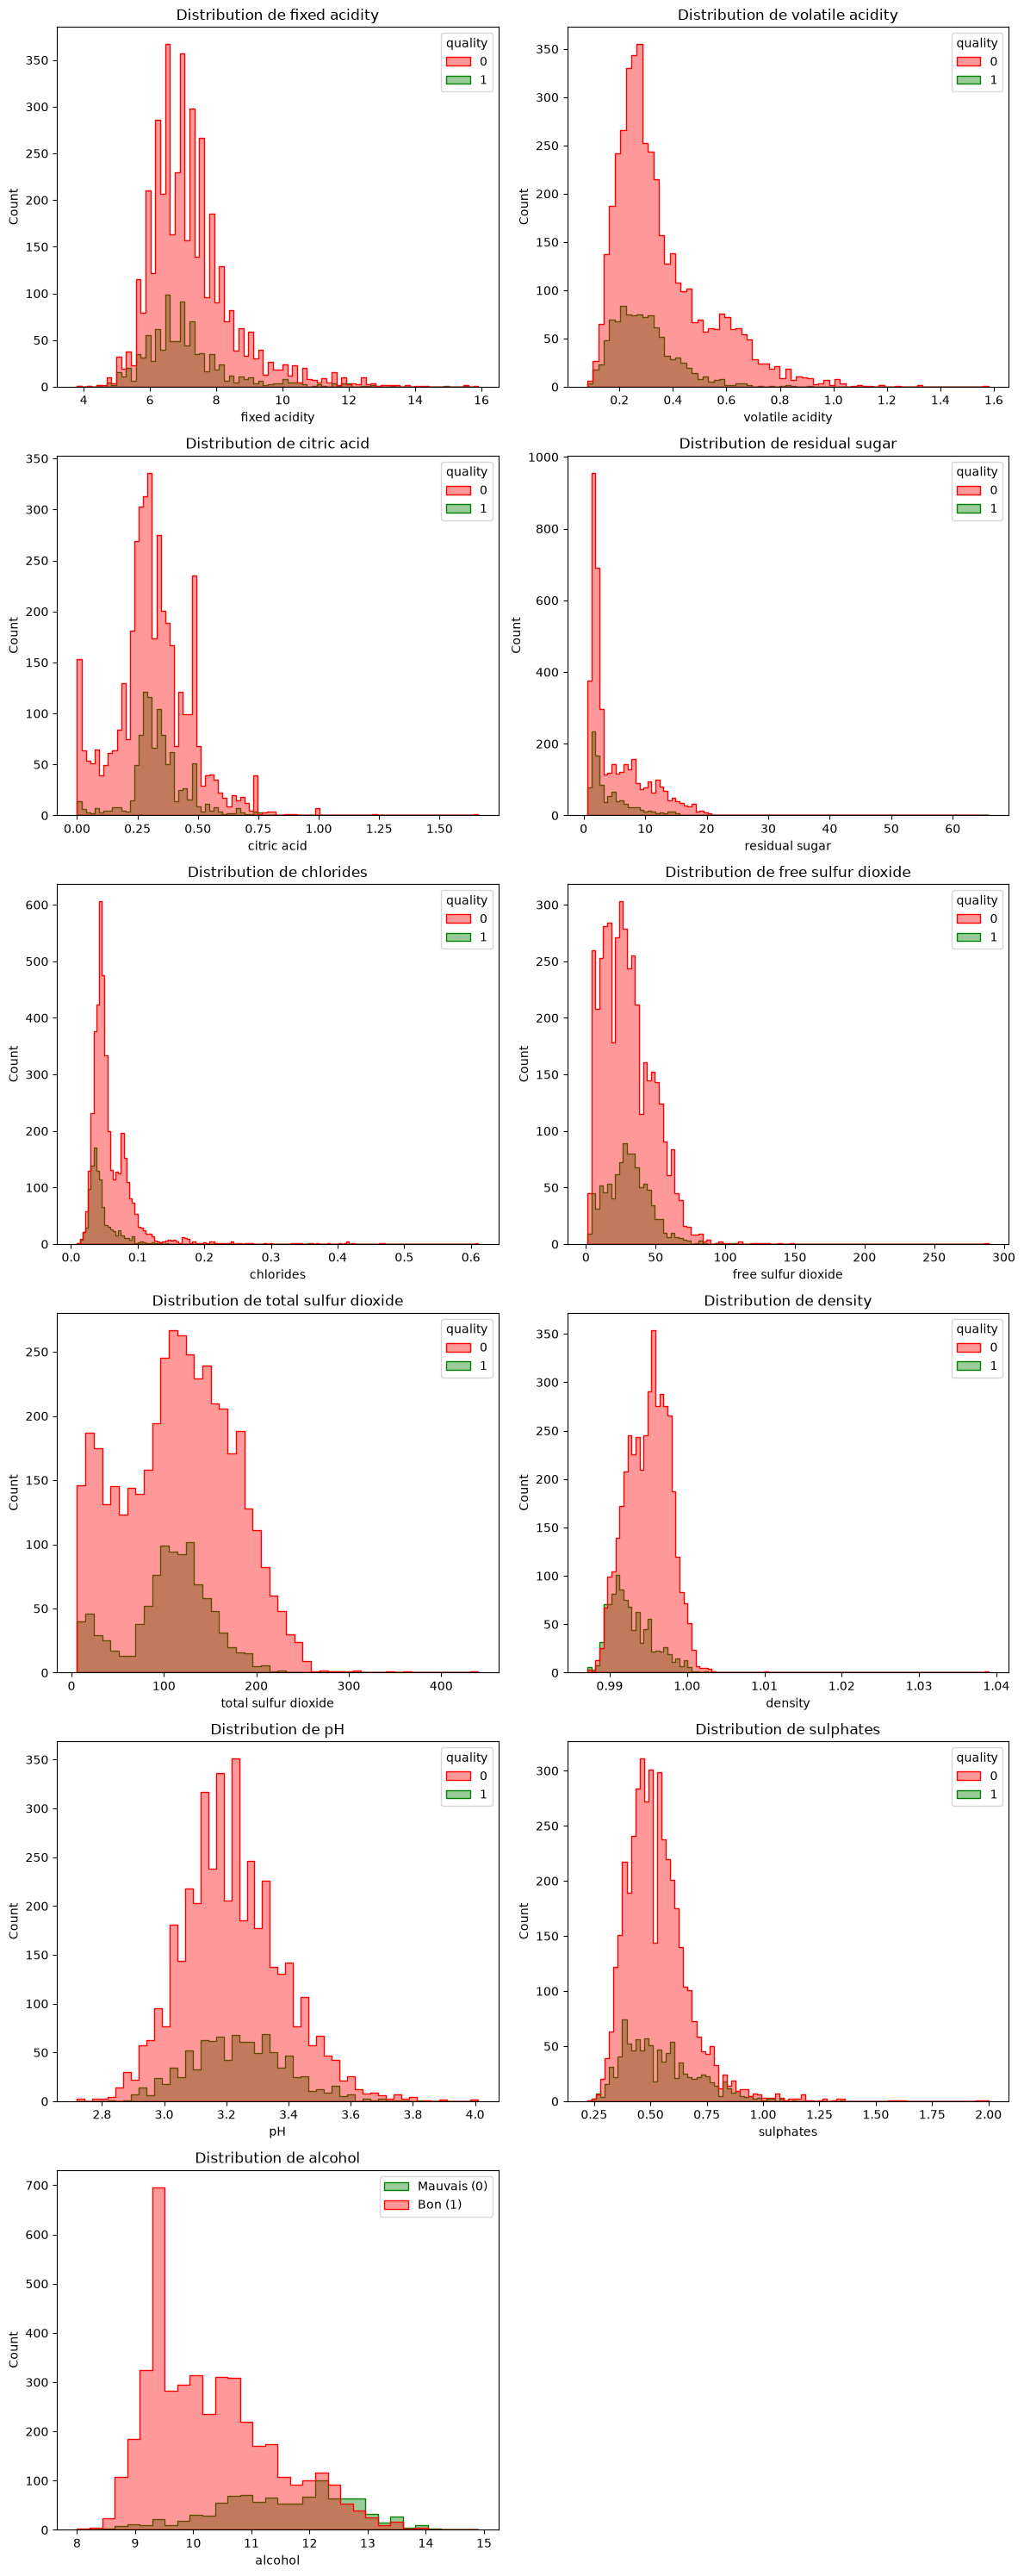

In [30]:
feature_cols = [col for col in df.columns if col not in ["color", "quality"]]

n_cols = 2
n_rows = math.ceil(len(feature_cols) / n_cols) # calcul l'arrondi superieur


fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()  

for i, col in enumerate(feature_cols):
    sns.histplot(
        data=df,
        x=col,
        hue="quality",
        element="step",  
        palette={"0" : "red", "1" : "green"},
        ax=axes[i],
        alpha=0.4
    )
    axes[i].set_title(f"Distribution de {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.legend(labels=["Mauvais (0)", "Bon (1)"])
plt.show()

---

L'analyse univariée des histogrammes montre un chevauchement quasi total des distributions entre les vins de classe `0` et `1` pour les caractéristiques physico-chimiques. Aucune variable prise de manière isolée ne possède un pouvoir discriminant suffisant. Cela confirme la nécessité de recourir à des **modèles de classification multivariés non linéaires** capables de capturer les interactions entre plusieurs variables simultanément. 

---

<h4 style="color:green">3.7.4) Analyse des moyennes groupées <code>groupby</code></h4>

In [31]:
df_corr.groupby("quality").mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,color
quality,,,,,,,,,,,,
0,7.246996,0.355879,0.314175,5.233229,0.059561,29.939109,115.95755,0.994958,3.220914,0.530694,10.309587,0.727441
1,7.079237,0.293930,0.336947,4.259118,0.044421,30.453419,106.21110,0.992727,3.240684,0.544737,11.573175,0.817641


---

Le tableau des moyennes par classe met en évidence des différences de profil entre les deux groupes. Les vins de qualité supérieure $(1)$ se caractérisent en moyenne par un taux d'alcool plus élevé ($11,43\ \%$ contre $10,26\ \%$) ainsi que par une acidité volatile ($0,29$ contre $0,35$) et un niveau de chlorures plus faibles. À l'inverse, des variables comme le $pH$ ou le dioxyde de soufre libre conservent des valeurs moyennes quasi identiques d'une classe à l'autre

---

<h4 style="color:green">3.7.5) Test de normalité <code>Shapiro-Test</code></h4>

$$
W = \frac{(\sum_{i=1}^n a_{i} \cdot x_{(i)})^2}{}
$$

In [50]:
from scipy.stats import shapiro

In [53]:
stat, p_value = shapiro(df_corr)

print(f'Statistique W = {stat:.4f}')
print(f'P-value = {p_value:.4f}')

Statistique W = 0.4232
P-value = 0.0000


<h2 style="font-weight:bolder">IV) Analyse en Composante Principale (ACP)</h2>

Les analyses **univariées** et **bivariées** n'ayant pas permis d'identifier de variables ou de seuils simples pour discriminer les classes $0$ et $1$, nous avons recours à une **Analyse en Composantes Principales (ACP)**.   

L'objectif est d'évaluer si une **combinaison linéaire multidimensionnelle** de l'ensemble des descripteurs physico-chimiques permet de faire émerger des **clusters distincts** pour la qualité du vin.

Si le premier plan factoriel confirme un chevauchement important des deux groupes, cela justifiera formellement l'abandon des **hypothèses de séparabilité linéaire** et la nécessité d'orienter la modélisation vers des **algorithmes non linéaires**.

<h3 style="font-weight:bolder; color:blue">4.1) Normalisation des données</h3>

Avant de procédé à notre ACP nous devons dans un premier temps standardisé nos données car le `df.describe()` à montrer que nos données n'étaient pas toutes à la même échelle, cette normalisation permettra de nous assurer que chaque variable ait une influence équitable sur l'analyse.

$$
Z_{ij} = \frac{x_{ij} - \bar{x}_{j}}{\sigma_{j}}
$$

Où 

- $x_{ij}$ représente l'occurence $i$ de la variable $j$
- $\bar{x}_{j}$ représente la moyenne de la variable $j$
- $\sigma_{j}$ représente l'écart-type de la variable $j$

Pour cela, nous avons développer la fonction `norm` qui prend en paramètre un dataframe et renvoie un dataframe normalisé.

--- 

**Pour l'instanciation du dataframe normalisé :**

```python
df_norm = norm(df)

```

In [32]:
def norm(df : pd.DataFrame) -> pd.DataFrame:
    return (df - df.mean())/df.std()

In [33]:
df_norm = norm(df_corr.drop("quality", axis=1))

<h3 style="font-weight:bolder; color:blue">4.2) Valeurs propre et Vecteurs propre</h3>

Dans l'ACP :

- Les **valeurs propres** mesurent la quantité de variance expliquée par chaque composante principale. Une valeur propre élevée indique qu'une composante capture une grande partie de la variabilité des données.
- Les **vecteurs propres** définissent les directions des nouvelles composantes principales. Chaque vecteur propre représente un axe du nouvel espace transformé.

**Formules fondamentales** :

- La relation entre la matrice $A$, les vecteurs propres $V$ et les valeurs propres $\lambda$ est donnée par :

$$
A \cdot V = \lambda \cdot V
$$

- $C$ est la matrice de corrélation de nos données définie par :

$$
C = \frac{1}{n} X_{cr}^T \cdot X_{cr}
$$

Où

- $n$ est le nombre d'observations
- $X_{cr}$ est la matrice des données centrée réduite

---

Pour les trouver : 

$$
det(C - \lambda \cdot I) = 0
$$

**Dans notre code python on utilise simplement**

```python

matrix_corr = df.corr()

val_propre, vec_propre = np.linalg.eig(matrix_corr)
```

---

Pour nous faciliter nous avons directement définit une fonction `acp` qui prend en paramètre un dataframe normalisé et qui renvoie :

- valeurs propre
- vecteurs propre
- Les données à projeter dans nos composantes principales

In [34]:
def acp(df_norm):
    matrix_corr = df_norm.corr()
    val_propre, vec_propre = np.linalg.eig(matrix_corr)

    sorted_indices = np.argsort(val_propre)[::-1]
    val_propre = val_propre[sorted_indices]
    vec_propre = vec_propre[:, sorted_indices]

    projected_array = np.dot(df_norm, vec_propre)

    cols = [f"F{i+1}" for i in range(vec_propre.shape[1])]
    df_projected = pd.DataFrame(
        projected_array, columns=cols, index=df_norm.index
    )

    return val_propre, vec_propre, df_projected

In [35]:
val_propre, vec_propre, df_projected = acp(df_norm)

<h3 style="font-weight:bolder; color:blue">4.3) Inertie en ACP</h3>

Comme nous l'avons expliqué précédemment, les **valeurs propres** mesurent la **quantité de variances expliquées** pour chaque composante. L'**inertie totale** représente la **variance globale des données**, tandis que l'**inertie expliquée** correspond à la part de cette **variance capturée par les composantes principales retenues**. 

Ces notions sont fondamentales en ACP, car elles permettent de réduire la dimension des données tout en conservant un maximum d'information.

`Inertie totale`

$$
I_{totale} = \sum_{j=1}^{p} \lambda_{j}
$$

Où 

- $\lambda_{j}$ représente la valeur propre de la $j$-ième composante
- $p$  représente l'ensemble des composantes

---

`Inertie expliquee`

$$
I_{expliquée} = \frac{\sum_{j=1}^k \lambda_{j}}{\sum_{j=1}^p \lambda_{j}} 
$$

Où 

- $\lambda_{j}$ représente la valeur propre de la $j$-ième composante
- $k$ représente les composantes qui seront séléctionnées pour la projection ($k=2$ ou $k=3$)

In [36]:
inertie_tot_df = sum(val_propre)

print(f"L'inertie totale pour les données de base est : {inertie_tot_df}")

L'inertie totale pour les données de base est : (12.000000000000005+0j)


Text(0.5, 1.0, 'Inertie expliquée (Données réelles)')

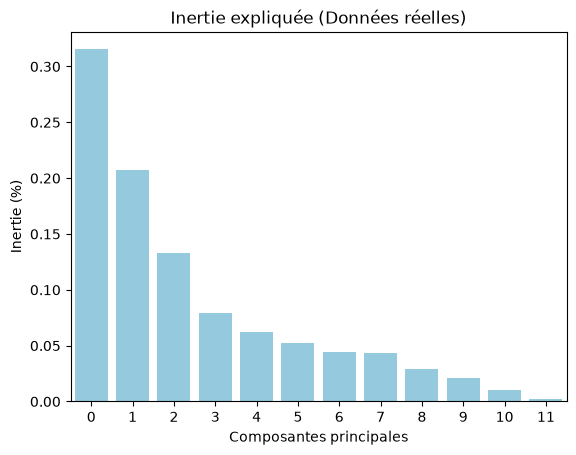

In [37]:
inertie_exp_df = val_propre / inertie_tot_df

sns.barplot(inertie_exp_df, color="skyblue")
plt.xlabel("Composantes principales")
plt.ylabel("Inertie (%)")
plt.title("Inertie expliquée (Données réelles)")

La somme des inerties des deux premières composantes parviennent à expliquer $52$% de la variabilité.

In [38]:
first_compo_df = inertie_exp_df[0] + inertie_exp_df[1]

print(f"Les deux premières composantes pour les données de base expliquent : {round(int(first_compo_df*100),4)}% de la variabilité")

Les deux premières composantes pour les données de base expliquent : 52% de la variabilité


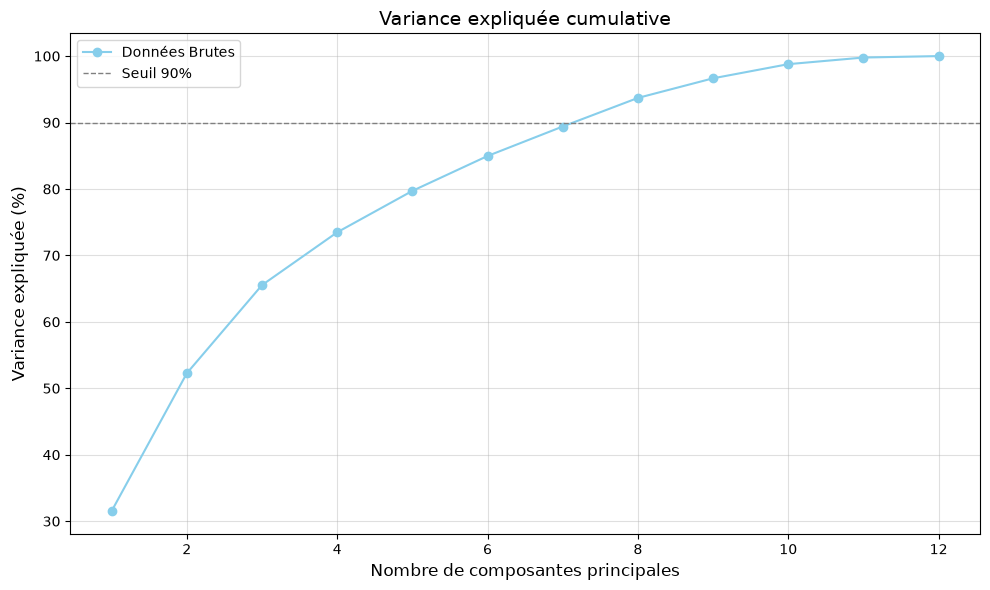

In [39]:
variance_expliquee = np.cumsum(val_propre / np.sum(val_propre)) * 100
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(val_propre) + 1), variance_expliquee, marker='o', label="Données Brutes", color="skyblue")
plt.title("Variance expliquée cumulative", fontsize=14)
plt.xlabel("Nombre de composantes principales", fontsize=12)
plt.ylabel("Variance expliquée (%)", fontsize=12)
plt.axhline(y=90, color='gray', linestyle='--', linewidth=1, label="Seuil 90%")  # Ligne de seuil
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()

plt.tight_layout()
plt.show()

In [40]:
seuil = 90
nb_composantes = np.argmax(variance_expliquee >= seuil) + 1
print(f"Il faut {nb_composantes} composantes pour expliquer au moins {seuil}% de la variance.")

Il faut 8 composantes pour expliquer au moins 90% de la variance.


<h3 style="font-weight:bolder; color:blue">4.4) Projection dans les composantes principales</h3>

<Axes: xlabel='F1', ylabel='F2'>

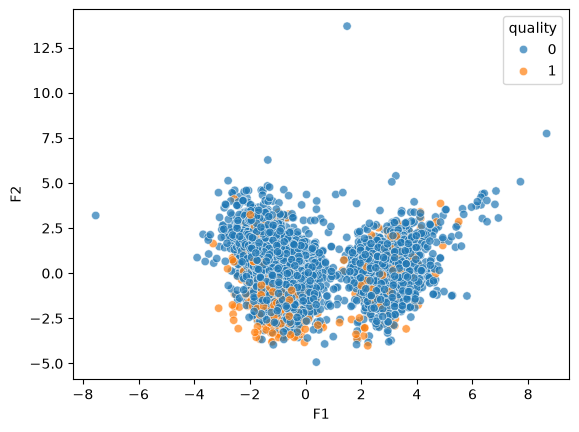

In [41]:
df_projected["quality"] = df["quality"]

sns.scatterplot(
    data=df_projected,
    x="F1",
    y="F2",
    alpha=0.7,
    hue="quality"
)

**Interprétation de la projection des données dans les composantes principales**

Les deux premières composantes principales cumulent $52\%$ de l'inertie totale du nuage de points.Ce niveau d'inertie expliquée indique que la représentation bidimensionnelle engendre une perte d'information non négligeable ($48\%$). 

La superposition des classes observée sur le premier plan factoriel **(F1, F2)** confirme qu'aucune combinaison linéaire simple ne permet de séparer les bons vins des mauvais.

<h2 style="font-weight:bolder">V) Modélisation et classification</h2>

L'**Analyse Exploratoire des Données (EDA)** a mis en évidence plusieurs caractéristiques fondamentales du jeu de données, imposant des choix méthodologiques précis pour la phase de modélisation :

1. **Un fort déséquilibre de classes** : La distribution cible présente 80 % de vins ordinaires (classe 0) contre 20 % de bons vins (classe 1). L'évaluation des modèles ne pourra donc pas s'appuyer sur l'exactitude globale (accuracy), mais se concentrera sur le F1-Score, le Rappel (Recall) et l'AUC-ROC sur la classe minoritaire. Les algorithmes intégreront un repondérage des classes (class_weight='balanced').

2. **L'absence de séparabilité linéaire simple** : L'analyse univariée a révélé un chevauchement quasi total des distributions pour la majorité des variables physico-chimiques. De plus, le premier plan factoriel de l'ACP, bien qu'expliquant 52 % de l'inertie globale, a confirmé l'incapacité des combinaisons linéaires à isoler la classe 1

3. **Le besoin d'interactions multivariées non linéaires** : Bien que des tendances légères se dégagent sur l'alcool (+0,39) et la densité (-0,28), la discrimination optimale repose sur des relations complexes et des seuils croisés entre plusieurs descripteurs (acidité volatile, chlorures, $pH$).

<h3 style="font-weight:bolder; color:blue">5.1) Features X Target</h3>

In [42]:
X = df_norm

In [43]:
y = df["quality"].astype(int)

<h3 style="font-weight:bolder; color:blue">5.2) Séparation des données</h3>

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4256, 12)
(1064, 12)
(4256,)
(1064,)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


from xgboost import XGBClassifier

In [48]:
model_dict = {
    "Logistic regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "DecisionTree" : DecisionTreeClassifier(),
    "RandomForest" : RandomForestClassifier(),
    "XGBoost" : XGBClassifier(),
    "SVM" : SVC()
}

=== Logistic regression ===

Score d'entrainement : 0.83 %
Score de test : 0.83 %

              precision    recall  f1-score   support

           0       0.84      0.96      0.90       848
           1       0.66      0.28      0.40       216

    accuracy                           0.83      1064
   macro avg       0.75      0.62      0.65      1064
weighted avg       0.80      0.83      0.80      1064



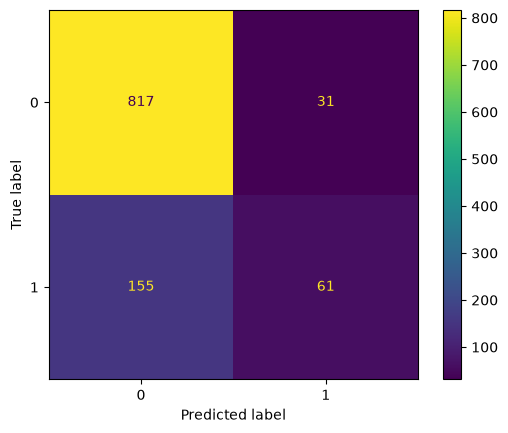

=== KNN ===

Score d'entrainement : 0.88 %
Score de test : 0.84 %

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       848
           1       0.64      0.45      0.53       216

    accuracy                           0.84      1064
   macro avg       0.75      0.69      0.72      1064
weighted avg       0.82      0.84      0.83      1064



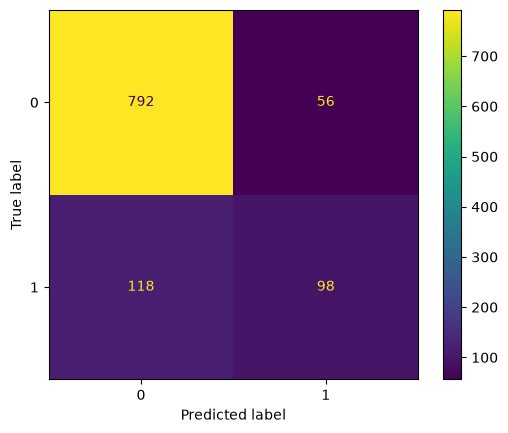

=== DecisionTree ===

Score d'entrainement : 1.00 %
Score de test : 0.79 %

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       848
           1       0.48      0.47      0.47       216

    accuracy                           0.79      1064
   macro avg       0.67      0.67      0.67      1064
weighted avg       0.79      0.79      0.79      1064



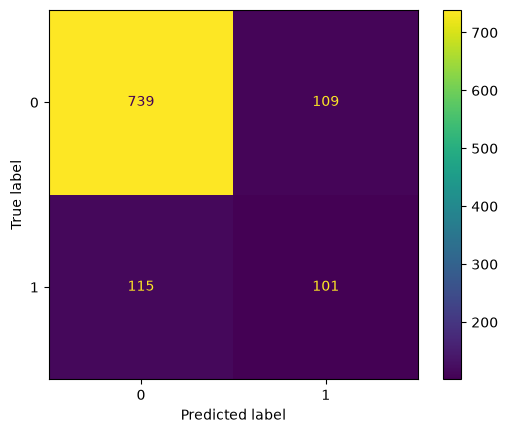

=== RandomForest ===

Score d'entrainement : 1.00 %
Score de test : 0.84 %

              precision    recall  f1-score   support

           0       0.86      0.96      0.91       848
           1       0.73      0.38      0.50       216

    accuracy                           0.84      1064
   macro avg       0.79      0.67      0.70      1064
weighted avg       0.83      0.84      0.83      1064



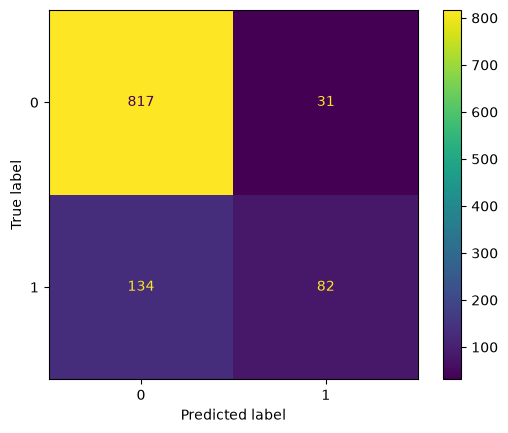

=== XGBoost ===

Score d'entrainement : 1.00 %
Score de test : 0.84 %

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       848
           1       0.68      0.44      0.53       216

    accuracy                           0.84      1064
   macro avg       0.77      0.69      0.72      1064
weighted avg       0.83      0.84      0.83      1064



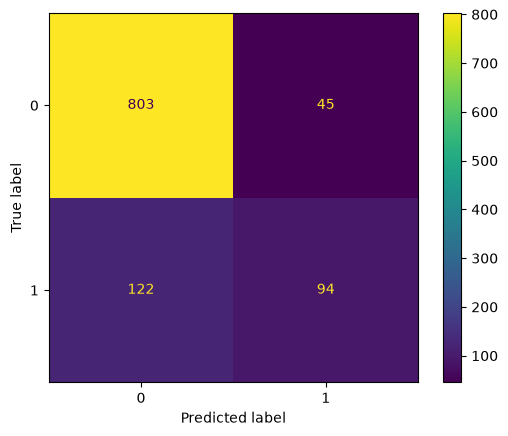

=== SVM ===

Score d'entrainement : 0.85 %
Score de test : 0.83 %

              precision    recall  f1-score   support

           0       0.84      0.98      0.90       848
           1       0.77      0.26      0.39       216

    accuracy                           0.83      1064
   macro avg       0.80      0.62      0.65      1064
weighted avg       0.82      0.83      0.80      1064



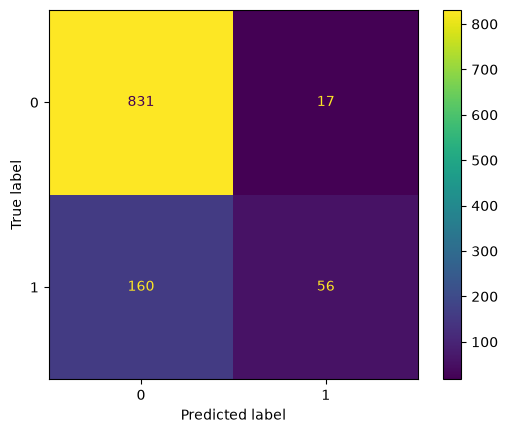

In [49]:
for key, model in model_dict.items():
    print(f"=== {key} ===\n")

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"Score d'entrainement : {train_acc:.2f} %")
    print(f"Score de test : {test_acc:.2f} %\n")

    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
    disp.plot()

    plt.show()
    

| Modèle | Accuracy | Précision (0 / 1) | Rappel (0 / 1) | F1-score (0 / 1) | Constat majeur |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Logistic Regression** | 83% | 0.84 / 0.66 | 0.96 / 0.28 | 0.90 / 0.40 | Baseline linéaire ; ignore la classe 1 (Rappel 27%) |
| **SVM** | 84% | 0.85 / 0.77 | 0.98 / 0.26 | 0.90 / 0.39 | Très conservateur ; privilégie fortement la classe 0 |
| **KNN** | 84% | 0.87 / 0.64 | 0.93 / 0.45 | 0.90 / 0.53 | Capture locale limitée par la densité de la classe 0 |
| **Decision Tree** | 78% | 0.86 / 0.46 | 0.87 / 0.44 | 0.86 / 0.45 | Bon rappel sur la classe 1, mais surapprentissage massif (100% Train) |
| **Random Forest** | 84% | 0.86 / 0.72 | 0.96 / 0.38 | 0.91 / 0.50 | Nette progression de la précision (77%) via le Bagging |
| **XGBoost** | **84%** | **0.87 / 0.68** | **0.95 / 0.44** | **0.91 / 0.53** | **Meilleur modèle** (Meilleur équilibre F1-score sur la classe 1) |

Après entrainement des différents modèles on peut commencer à interpréter les différents résultats